# **Count number of samples**

In [1]:
import os
import glob

# Correct deep paths based on your folder structure
TRAIN_IMAGES_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/images"
TRAIN_LABELS_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/labels"

TIER3_IMAGES_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images"
TIER3_LABELS_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/labels"

TEST_IMAGES_DIR  = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images"

def build_data_pairs(images_dir, labels_dir):
    """Pairs pre-disaster images with their corresponding post-disaster images and JSON labels."""
    pairs = []
    # Search specifically for pre_disaster images to avoid duplication
    pre_images = sorted(glob.glob(os.path.join(images_dir, "*_pre_disaster.png")))
    
    for pre_img in pre_images:
        base_name = os.path.basename(pre_img)
        
        # Derive the names for post-image and labels
        post_img = pre_img.replace("_pre_disaster.png", "_post_disaster.png")
        pre_label = os.path.join(labels_dir, base_name.replace(".png", ".json"))
        post_label = os.path.join(labels_dir, base_name.replace("_pre_disaster.png", "_post_disaster.json"))
        
        # Ensure all corresponding files actually exist before adding them
        if os.path.exists(post_img) and os.path.exists(pre_label) and os.path.exists(post_label):
            pairs.append({
                "pre_image": pre_img,
                "post_image": post_img,
                "pre_label": pre_label,
                "post_label": post_label
            })
            
    return pairs

# Gather pairs from both training pools
train_set_pairs = build_data_pairs(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
tier3_set_pairs = build_data_pairs(TIER3_IMAGES_DIR, TIER3_LABELS_DIR)
total_training_pairs = train_set_pairs + tier3_set_pairs

# Count unannotated test images
test_images_count = len(glob.glob(os.path.join(TEST_IMAGES_DIR, "*.png")))

print(f" Paired Train Set: {len(train_set_pairs)} complete items.")
print(f" Paired Tier 3 Set: {len(tier3_set_pairs)} complete items.")
print(f" Total Combined Training Pairs: {len(total_training_pairs)}")
print(f" Unlabeled Test Images: {test_images_count} files.")

 Paired Train Set: 2799 complete items.
 Paired Tier 3 Set: 6369 complete items.
 Total Combined Training Pairs: 9168
 Unlabeled Test Images: 1866 files.


# **Merge train set and tier3 set ,then split into train and validation**

In [2]:
import os
import glob
from sklearn.model_selection import train_test_split

# 1. Define the exact, deep paths based on your folder structure
TRAIN_IMAGES_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/images"
TRAIN_LABELS_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/labels"

TIER3_IMAGES_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images"
TIER3_LABELS_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/labels"

def build_data_pairs(images_dir, labels_dir):
    """
    Scans a folder for pre_disaster images, locates their matching 
    post_disaster images and JSON labels, and bundles them into pairs.
    """
    pairs = []
    # We target pre_disaster images to establish our baseline mapping
    pre_images = sorted(glob.glob(os.path.join(images_dir, "*_pre_disaster.png")))
    
    for pre_img in pre_images:
        base_name = os.path.basename(pre_img)
        
        # Derive corresponding post-image and label file paths
        post_img = pre_img.replace("_pre_disaster.png", "_post_disaster.png")
        pre_label = os.path.join(labels_dir, base_name.replace(".png", ".json"))
        post_label = os.path.join(labels_dir, base_name.replace("_pre_disaster.png", "_post_disaster.json"))
        
        # Only add to our list if all 4 required files exist
        if os.path.exists(post_img) and os.path.exists(pre_label) and os.path.exists(post_label):
            pairs.append({
                "pre_image": pre_img,
                "post_image": post_img,
                "pre_label": pre_label,
                "post_label": post_label
            })
            
    return pairs

# 2. Extract and pair files from both independent dataset directories
print(" Scanning directories and pairing files...")
train_set_pairs = build_data_pairs(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
tier3_set_pairs = build_data_pairs(TIER3_IMAGES_DIR, TIER3_LABELS_DIR)

# 3. Combine both subsets into a single master training pool
total_training_pairs = train_set_pairs + tier3_set_pairs

print(f"   ↳ Found {len(train_set_pairs)} pairs in Train folder.")
print(f"   ↳ Found {len(tier3_set_pairs)} pairs in Tier3 folder.")
print(f" Total combined data pool: {len(total_training_pairs)} pairs.")

# 4. Perform the Split (85% Train, 15% Validation)
# random_state=42 guarantees the exact same shuffle if you rerun the cell
train_data, val_data = train_test_split(
    total_training_pairs, 
    test_size=0.15, 
    random_state=42
)

print("\n Final Split Results:")
print(f"    Training Set Size (85%):   {len(train_data)} item pairs")
print(f"    Validation Set Size (15%): {len(val_data)} item pairs")

# --- Verify a sample item to ensure paths are correct ---
print("\n Sample Validation Item Verification:")
sample = val_data[0]
print(f"    Pre-Image File:  {os.path.basename(sample['pre_image'])}")
print(f"    Post-Image File: {os.path.basename(sample['post_image'])}")
print(f"    Pre-Label File:  {os.path.basename(sample['pre_label'])}")
print(f"    Post-Label File: {os.path.basename(sample['post_label'])}")

 Scanning directories and pairing files...
   ↳ Found 2799 pairs in Train folder.
   ↳ Found 6369 pairs in Tier3 folder.
 Total combined data pool: 9168 pairs.

 Final Split Results:
    Training Set Size (85%):   7792 item pairs
    Validation Set Size (15%): 1376 item pairs

 Sample Validation Item Verification:
    Pre-Image File:  midwest-flooding_00000221_pre_disaster.png
    Post-Image File: midwest-flooding_00000221_post_disaster.png
    Pre-Label File:  midwest-flooding_00000221_pre_disaster.json
    Post-Label File: midwest-flooding_00000221_post_disaster.json


# **Phase1-UNET on post disater images**

In [3]:
# Install libraries (agar runtime restart hua ho)
!pip install -q segmentation-models-pytorch albumentations shapely

import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# CUDA GPU target device binding configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Phase 2 Environment bound to GPU Node: {device}")
if torch.cuda.is_available():
    print(f"🎮 Active GPU Device Name: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.

In [8]:
import os
import json
from shapely import wkt
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2


# Squeeze karne ke bajaye original density barkarar rakhne ke liye transforms:
TRAIN_TRANSFORMS = A.Compose([
    A.RandomCrop(width=512, height=512), # Badi resolution se bina quality kharab kiye crop nikala
    A.Resize(256, 256),                  # Ab scale down kiya (ab pixels miss nahi honge)
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class PostOnlyJSONToMaskDataset(Dataset):
    def __init__(self, data_pairs, transforms=None):
        """
        Args:
            data_pairs (list): train_data ya val_data ki list jisme dict keys hain.
            transforms: Image processing aur augmentation pipelines.
        """
        self.data_pairs = data_pairs
        self.transforms = transforms
        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        
    def __len__(self):
        return len(self.data_pairs)
        
    def __getitem__(self, idx):
        item = self.data_pairs[idx]
        img_path = item["post_image"]
        json_path = item["post_label"]
        
        # Load Post Image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape
        
        # --- 🚀 ADVANCED IMAGE PROCESSING LAYER ---
        # 1. CLAHE for local contrast extraction
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        cl = self.clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        image = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        
        # 2. Bilateral Filter to smooth textures but protect building edges
        image = cv2.bilateralFilter(image, d=5, sigmaColor=50, sigmaSpace=50)
        # ------------------------------------------
        
        # Build empty mask footprint array
        generated_mask = np.zeros((h, w), dtype=np.uint8)
        
        # Parse JSON and draw building polygons using Shapely
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                data = json.load(f)
                
            for feature in data.get('features', {}).get('xy', []):
                wkt_str = feature['wkt']
                poly = wkt.loads(wkt_str)
                coords = np.array(poly.exterior.coords, dtype=np.int32)
                cv2.fillPoly(generated_mask, [coords], 1)
                    
        # Apply transformation checks
        if self.transforms:
            augmented = self.transforms(image=image, mask=generated_mask)
            image = augmented['image']
            mask = augmented['mask'].float().unsqueeze(0)
        else:
            image = torch.tensor(image).permute(2, 0, 1).float()
            mask = torch.tensor(generated_mask).float().unsqueeze(0)
            
        return image, mask

print("✅ Target Post-Disaster Dataset Engine with CLAHE & Bilateral Filter compiled successfully!")
        
 
 

✅ Target Post-Disaster Dataset Engine with CLAHE & Bilateral Filter compiled successfully!


In [9]:
# Initialize datasets directly passing your arrays
train_dataset = PostOnlyJSONToMaskDataset(data_pairs=train_data, transforms=TRAIN_TRANSFORMS)
val_dataset = PostOnlyJSONToMaskDataset(data_pairs=val_data, transforms=TRAIN_TRANSFORMS)

# Build optimization loaders for TPU node execution loops
BATCH_SIZE = 16 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("🚀 Data loaders verified and locked to target split distribution arrays!")
print(f"📊 Train Batches: {len(train_loader)} | Validation Batches: {len(val_loader)}")

🚀 Data loaders verified and locked to target split distribution arrays!
📊 Train Batches: 487 | Validation Batches: 86


In [11]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

# Initialize U-Net architecture with an efficient backbone
unet_model = smp.Unet(
    encoder_name="efficientnet-b3", 
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1,                      
    activation=None                 
).to(device)

# Hybrid Objective Formulation
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary')

def hybrid_criterion(predictions, targets):
    return (0.4 * bce_loss(predictions, targets)) + (0.6 * dice_loss(predictions, targets))

optimizer_unet = optim.AdamW(unet_model.parameters(), lr=3e-4, weight_decay=1e-4)
print("✅ U-Net compiled with AdamW and Post-Only Hybrid Loss metrics.")

✅ U-Net compiled with AdamW and Post-Only Hybrid Loss metrics.


In [12]:
import numpy as np
from tqdm.auto import tqdm

# History dictionary extended to track segmentation performance metrics
history = {
    "train_loss": [], "val_loss": [],
    "train_iou": [], "val_iou": [],
    "train_f1": [], "val_f1": []
}

def calculate_metrics(outputs, masks, smooth=1e-6):
    """
    Computes batch-level IoU and F1-Score (Dice Coefficient) using tensors on GPU.
    """
    # Convert logits to binary predictions (0 or 1) using a 0.5 threshold
    preds = (torch.sigmoid(outputs) > 0.5).float()
    masks = masks.float()
    
    # Flatten tensors to compute global intersection and union over the batch
    preds_flat = preds.view(-1)
    masks_flat = masks.view(-1)
    
    intersection = (preds_flat * masks_flat).sum()
    total_pixels = preds_flat.sum() + masks_flat.sum()
    union = total_pixels - intersection
    
    # Calculate scores with a smooth factor to prevent division-by-zero errors
    iou = (intersection + smooth) / (union + smooth)
    f1 = (2.0 * intersection + smooth) / (total_pixels + smooth)
    
    return iou.item(), f1.item()

def train(model, loader, optimizer, epoch_idx, total_epochs):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_f1 = 0.0
    
    progress_bar = tqdm(
        loader, 
        desc=f"🎬 Epoch [{epoch_idx}/{total_epochs}] Train", 
        leave=False
    )
    
    for images, masks in progress_bar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = hybrid_criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        # Performance metric capture
        batch_loss = loss.item()
        batch_iou, batch_f1 = calculate_metrics(outputs, masks)
        
        running_loss += batch_loss * images.size(0)
        running_iou += batch_iou * images.size(0)
        running_f1 += batch_f1 * images.size(0)
        
        # Real-time bar updates showcasing both loss and structural accuracy
        progress_bar.set_postfix(loss=f"{batch_loss:.4f}", IoU=f"{batch_iou:.4f}", F1=f"{batch_f1:.4f}")
        
    dataset_size = len(loader.dataset) if len(loader.dataset) > 0 else 1
    return running_loss / dataset_size, running_iou / dataset_size, running_f1 / dataset_size

def validate(model, loader):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_f1 = 0.0
    
    progress_bar = tqdm(
        loader, 
        desc="🔍 Validating", 
        leave=False
    )
    
    with torch.no_grad():
        for images, masks in progress_bar:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = hybrid_criterion(outputs, masks)
            
            batch_loss = loss.item()
            batch_iou, batch_f1 = calculate_metrics(outputs, masks)
            
            running_loss += batch_loss * images.size(0)
            running_iou += batch_iou * images.size(0)
            running_f1 += batch_f1 * images.size(0)
            
    dataset_size = len(loader.dataset) if len(loader.dataset) > 0 else 1
    return running_loss / dataset_size, running_iou / dataset_size, running_f1 / dataset_size

# --- START EXECUTION MANAGEMENT ---
EPOCHS = 50
best_loss = float('inf')

print("🚀 Launching Dynamic JSON-to-Mask U-Net Core Training on GPU...")

for epoch in range(EPOCHS):
    # Unpack updated multi-metric returns
    t_loss, t_iou, t_f1 = train(unet_model, train_loader, optimizer_unet, epoch + 1, EPOCHS)
    v_loss, v_iou, v_f1 = validate(unet_model, val_loader)
        
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_iou"].append(t_iou)
    history["val_iou"].append(v_iou)
    history["train_f1"].append(t_f1)
    history["val_f1"].append(v_f1)
    
    # Unified execution readout statement
    print(f"✨ Epoch [{epoch+1}/{EPOCHS}] Complete -> "
          f"Train Loss: {t_loss:.4f} | IoU: {t_iou:.4f} | F1: {t_f1:.4f} || "
          f"Val Loss: {v_loss:.4f} | Val IoU: {v_iou:.4f} | Val F1: {v_f1:.4f}")
    
    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(unet_model.state_dict(), "phase1_post_unet.pth")
        print("💾 Best snapshot validation weight saved to 'phase1_post_unet.pth'!\n")
    else:
        print("⏭️ Validation loss did not improve.\n")

🚀 Launching Dynamic JSON-to-Mask U-Net Core Training on GPU...


🎬 Epoch [1/50] Train:   0%|          | 0/487 [00:00<?, ?it/s]

🔍 Validating:   0%|          | 0/86 [00:00<?, ?it/s]

✨ Epoch [1/50] Complete -> Train Loss: 0.4155 | IoU: 0.3966 | F1: 0.5525 || Val Loss: 0.2754 | Val IoU: 0.4703 | Val F1: 0.6336
💾 Best snapshot validation weight saved to 'phase1_post_unet.pth'!



🎬 Epoch [2/50] Train:   0%|          | 0/487 [00:00<?, ?it/s]

...

🔍 Validating:   0%|          | 0/86 [00:00<?, ?it/s]

✨ Epoch [49/50] Complete -> Train Loss: 0.1773 | IoU: 0.6067 | F1: 0.7512 || Val Loss: 0.1850 | Val IoU: 0.5986 | Val F1: 0.7435
⏭️ Validation loss did not improve.



🎬 Epoch [50/50] Train:   0%|          | 0/487 [00:00<?, ?it/s]

🔍 Validating:   0%|          | 0/86 [00:00<?, ?it/s]

✨ Epoch [50/50] Complete -> Train Loss: 0.1777 | IoU: 0.6052 | F1: 0.7499 || Val Loss: 0.1876 | Val IoU: 0.5936 | Val F1: 0.7397
⏭️ Validation loss did not improve.



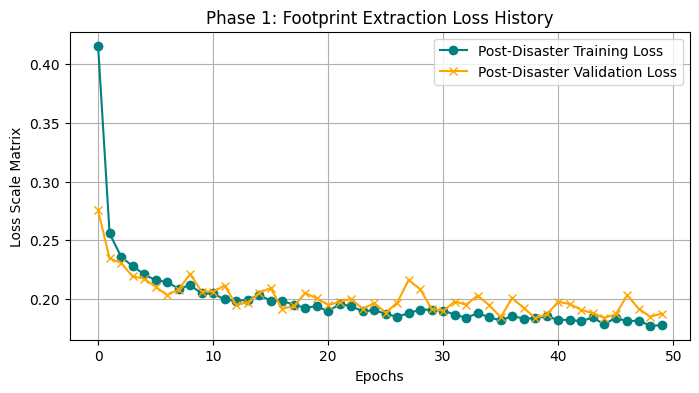

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Post-Disaster Training Loss", color="teal", marker="o")
plt.plot(history["val_loss"], label="Post-Disaster Validation Loss", color="orange", marker="x")
plt.title("Phase 1: Footprint Extraction Loss History")
plt.xlabel("Epochs")
plt.ylabel("Loss Scale Matrix")
plt.legend()
plt.grid(True)
plt.show()